In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs 

df = pd.read_csv("creditcard.csv")
X = df.select_dtypes(include=[np.number]).values 

X, _ = make_blobs(n_samples=1000, centers=3, random_state=42)

In [ ]:
inertia_list = []
silhouette_list = []
k_range = range(2, 7) 

print("Memulai proses clustering dan hyperparameter tuning...")

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    
    inertia_list.append(kmeans.inertia_)
    
    score = silhouette_score(X, labels)
    silhouette_list.append(score)
    
    print(f"K = {k} | Silhouette Score = {score:.4f}")

print("Proses clustering selesai!")

Memulai proses clustering dan hyperparameter tuning...
K = 2 | Silhouette Score = 0.7053
K = 3 | Silhouette Score = 0.8436
K = 4 | Silhouette Score = 0.6751
K = 5 | Silhouette Score = 0.5090
K = 6 | Silhouette Score = 0.3247
Proses clustering selesai!


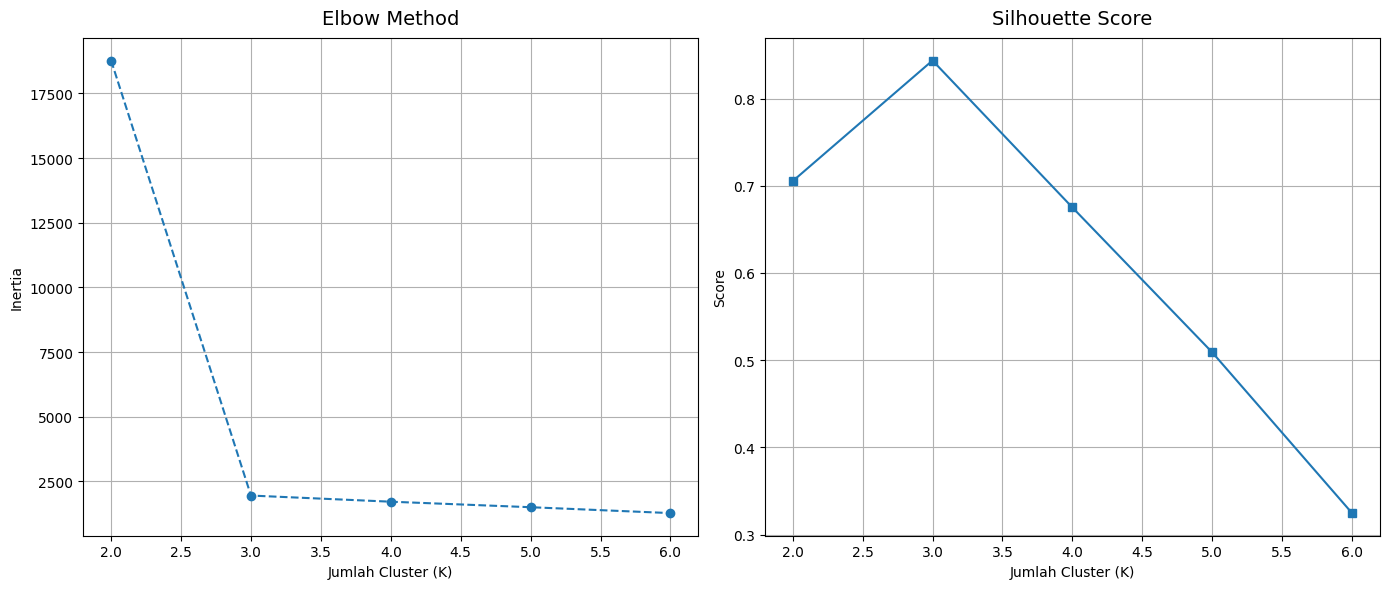

In [ ]:
# Membuat canvas dengan 1 baris dan 2 kolom (samping-sampingan)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Grafik Kiri: Elbow Method ---
ax1.plot(k_range, inertia_list, marker='o', linestyle='--', color='#1f77b4')
ax1.set_title('Elbow Method', fontsize=14, pad=10)
ax1.set_xlabel('Jumlah Cluster (K)')
ax1.set_ylabel('Inertia')
ax1.set_xticks(np.arange(2, 6.5, 0.5))
ax1.grid(True)

# --- Grafik Kanan: Silhouette Score ---
ax2.plot(k_range, silhouette_list, marker='s', linestyle='-', color='#1f77b4')
ax2.set_title('Silhouette Score', fontsize=14, pad=10)
ax2.set_xlabel('Jumlah Cluster (K)')
ax2.set_ylabel('Score')
ax2.set_xticks(np.arange(2, 6.5, 0.5))
ax2.grid(True)

plt.tight_layout()

plt.show()